In [1]:
import os
print(os.getcwd())

D:\Advanced-AI-Medical-Intelligence-Platform\notebooks


In [2]:
print(os.listdir("../dataset/chest_xray"))

['test', 'train', 'val']


In [3]:
train_dir = "../dataset/chest_xray/train"
val_dir = "../dataset/chest_xray/val"
test_dir = "../dataset/chest_xray/test"

In [4]:
import os

print("Train Exists:", os.path.exists(train_dir))
print("Validation Exists:", os.path.exists(val_dir))
print("Test Exists:", os.path.exists(test_dir))

Train Exists: True
Validation Exists: True
Test Exists: True


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4684 images belonging to 2 classes.
Found 585 images belonging to 2 classes.
Found 587 images belonging to 2 classes.


In [7]:
print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


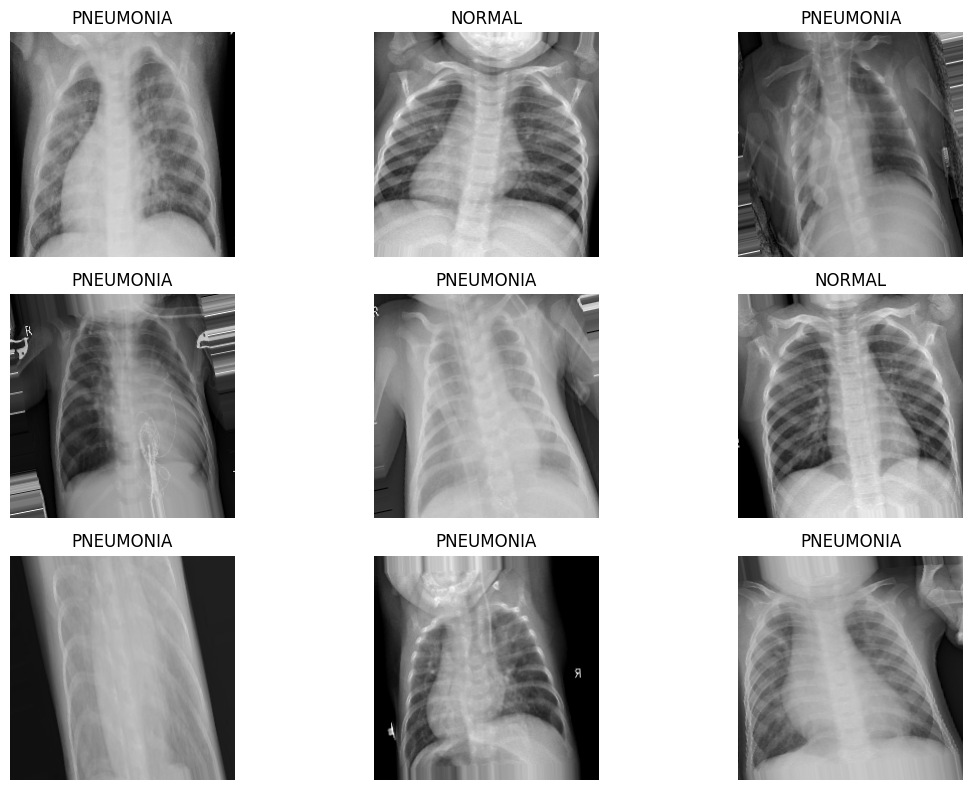

In [8]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title("PNEUMONIA" if labels[i] == 1 else "NORMAL")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.summary()

C:\Users\B.UDAY KIRAN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 52, 52, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      22,151,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,245,825 (84.86 MB)

 Trainable params: 22,245,377 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

os.makedirs("../models", exist_ok=True)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "../models/pneumonia_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [12]:
history = model.fit(
    train_generator,
    validation_data=val_generato  r,
    epochs=15,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 1061s 7s/step - accuracy: 0.8407 - loss: 1.1816 - val_accuracy: 0.7299 - val_loss: 42.4977
Epoch 2/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 1263s 9s/step - accuracy: 0.8811 - loss: 0.3281 - val_accuracy: 0.7299 - val_loss: 17.6214
Epoch 3/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 781s 5s/step - accuracy: 0.8877 - loss: 0.2958 - val_accuracy: 0.8906 - val_loss: 0.3493
Epoch 4/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 806s 5s/step - accuracy: 0.8980 - loss: 0.2523 - val_accuracy: 0.9368 - val_loss: 0.1809
Epoch 5/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 794s 5s/step - accuracy: 0.9150 - loss: 0.2543 - val_accuracy: 0.9385 - val_loss: 0.1713
Epoch 6/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 419s 3s/step - accuracy: 0.9193 - loss: 0.2240 - val_accuracy: 0.8308 - val_loss: 0.3978
Epoch 7/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 446s 3s/step - accuracy: 0.9056 - loss: 0.2338 - val_accuracy: 0.8308 - val_loss: 0.4001
Epoch 8/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 514s 3s/step - accuracy: 0.9073 - loss: 0.2369 - val_

In [13]:
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9216 - loss: 0.1776
Test Accuracy: 0.9216
Test Loss: 0.1776


In [14]:
import os

print(os.path.exists("../models/pneumonia_model.keras"))

True


In [15]:
import numpy as np

predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print(class_labels)

19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 675ms/step
['NORMAL', 'PNEUMONIA']


In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

              precision    recall  f1-score   support

      NORMAL       0.85      0.87      0.86       159
   PNEUMONIA       0.95      0.94      0.95       428

    accuracy                           0.92       587
   macro avg       0.90      0.90      0.90       587
weighted avg       0.92      0.92      0.92       587



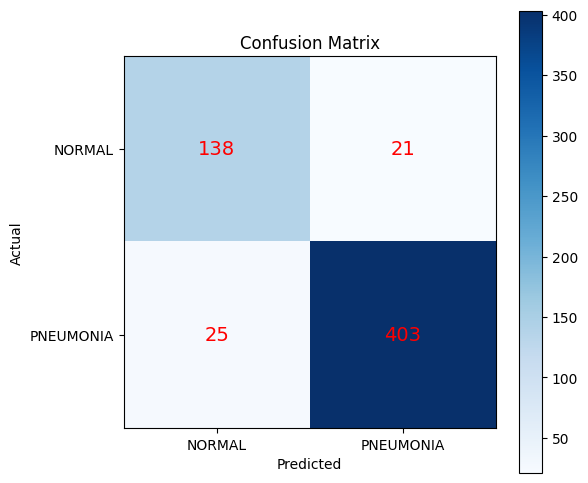

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,6))
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], class_labels)
plt.yticks([0,1], class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="red",
                 fontsize=14)

plt.show()

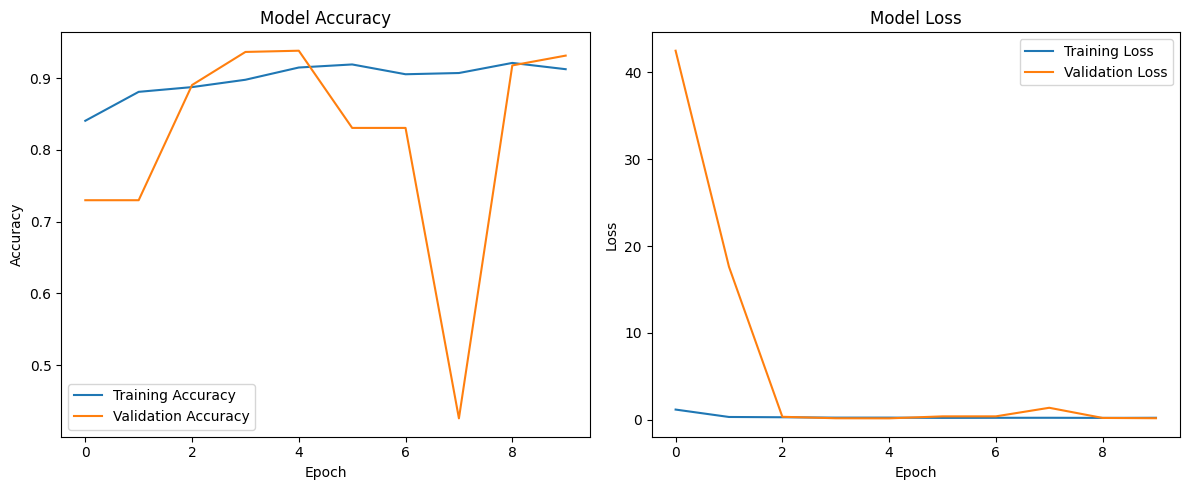

In [18]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [1]:
from tensorflow.keras.models import load_model

model = load_model("../models/pneumonia_model.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [3]:
import sys
import os

sys.path.append(os.path.abspath("../backend"))

from predict import predict_image

Loading model from: D:\Advanced-AI-Medical-Intelligence-Platform\backend\..\models\pneumonia_model.keras


In [5]:
import os

normal_path = "../dataset/chest_xray/test/NORMAL"

print(os.listdir(normal_path)[:10])

['IM-0028-0001.jpeg', 'IM-0029-0001.jpeg', 'IM-0075-0001.jpeg', 'IM-0079-0001.jpeg', 'IM-0085-0001.jpeg', 'IM-0086-0001.jpeg', 'IM-0099-0001.jpeg', 'IM-0103-0001.jpeg', 'IM-0107-0001.jpeg', 'IM-0110-0001.jpeg']


In [6]:
result = predict_image("../dataset/chest_xray/test/NORMAL/IM-0028-0001.jpeg")
print(result)

{'prediction': 'PNEUMONIA', 'confidence': 59.2}


In [7]:
import os

print(os.listdir("../dataset/chest_xray/test/PNEUMONIA")[:5])

['person1002_bacteria_2933.jpeg', 'person1004_bacteria_2935.jpeg', 'person1004_virus_1686.jpeg', 'person1007_virus_1690.jpeg', 'person100_bacteria_482.jpeg']


In [9]:
import os

print(os.listdir("../dataset/chest_xray/test/PNEUMONIA")[:10])

['person1002_bacteria_2933.jpeg', 'person1004_bacteria_2935.jpeg', 'person1004_virus_1686.jpeg', 'person1007_virus_1690.jpeg', 'person100_bacteria_482.jpeg', 'person1015_virus_1702.jpeg', 'person1020_virus_1710.jpeg', 'person1023_virus_1714.jpeg', 'person1039_bacteria_2973.jpeg', 'person1051_bacteria_2985.jpeg']


In [10]:
result = predict_image("../dataset/chest_xray/test/PNEUMONIA/person1004_virus_1686.jpeg")
print(result)

{'prediction': 'PNEUMONIA', 'confidence': 99.99}


In [11]:
print(result)

{'prediction': 'PNEUMONIA', 'confidence': 99.99}


In [12]:
for layer in model.layers:
    print(layer.name)

conv2d
batch_normalization
max_pooling2d
conv2d_1
batch_normalization_1
max_pooling2d_1
conv2d_2
batch_normalization_2
max_pooling2d_2
flatten
dense
dropout
dense_1
